In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from wordcloud import WordCloud

In [62]:
#ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [63]:
#loading the dataset
df = pd.read_csv("us_sentiment_analysis_ds.csv")

print("Columns in dataset:")
print(df.columns)
print(df.head())


Columns in dataset:
Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='object')
             tweet_id airline_sentiment  airline_sentiment_confidence  \
0  570306133677760513           neutral                        1.0000   
1  570301130888122368          positive                        0.3486   
2  570301083672813571           neutral                        0.6837   
3  570301031407624196          negative                        1.0000   
4  570300817074462722          negative                        1.0000   

  negativereason  negativereason_confidence         airline  \
0            NaN                        NaN  Virgin America   
1            NaN                     0.0000  Virgin America   
2            NaN      

In [64]:
# setting correct columns

text_col = 'text'
sent_col = 'airline_sentiment'

In [65]:
# Here we are going to clean the text
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text

df['clean_text'] = df[text_col].apply(clean_text)

In [66]:
#Here we are applying the machine learning concept called as feature engineering.
df['tweet_length'] = df['clean_text'].apply(len)
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))

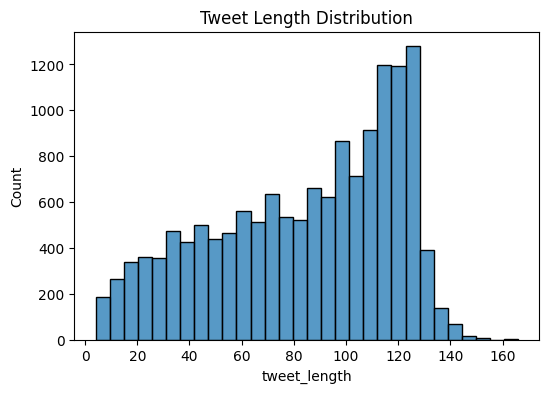

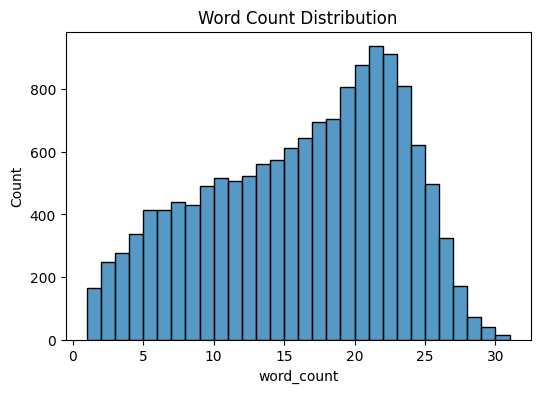

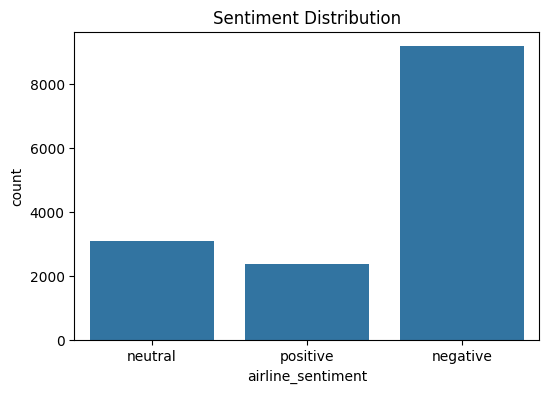

In [67]:
#here we are going to showcase or put the data into visualization.
#Tweet Length
plt.figure(figsize =(6,4))
sns.histplot(df['tweet_length'], bins=30)
plt.title("Tweet Length Distribution")
plt.show()

#word Count
plt.figure(figsize =(6,4))
sns.histplot(df['word_count'], bins=30)
plt.title("Word Count Distribution")
plt.show()

#Sentiment Distribution
plt.figure(figsize =(6,4))
sns.countplot(x='airline_sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

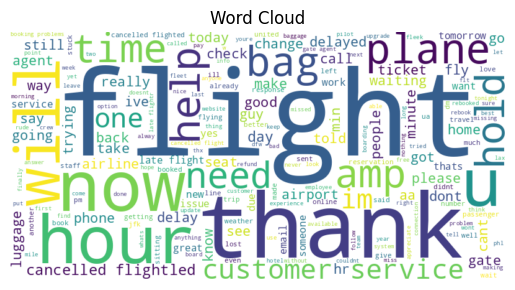

In [68]:
#Word Cloud
all_words = " ".join(df['clean_text'])

wc = WordCloud(width=800, height=400, background_color='white').generate(all_words)

plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud")
plt.show()

In [69]:
#Prepare data for ML
X = df['clean_text']
y = df[sent_col]

In [70]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [72]:
#TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


In [73]:
#Model Training
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

LogisticRegression(max_iter=1000)

In [74]:
#Prediction

y_pred = model.predict(X_test_vec)

In [76]:
#Evaluation

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\n Classification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8080601092896175

 Classification Report:

              precision    recall  f1-score   support

    negative       0.83      0.94      0.88      1889
     neutral       0.68      0.54      0.61       580
    positive       0.82      0.61      0.70       459

    accuracy                           0.81      2928
   macro avg       0.78      0.70      0.73      2928
weighted avg       0.80      0.81      0.80      2928



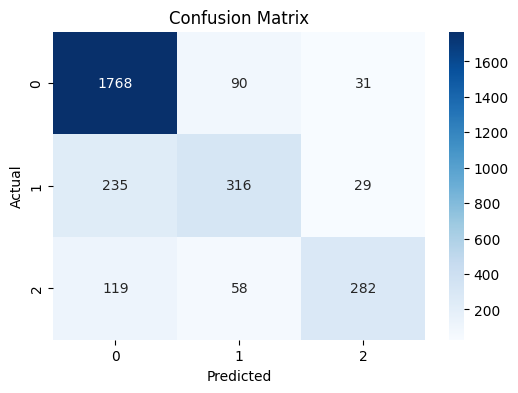

In [77]:
#Confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [78]:
#Sample Prediction
sample_text = ["The flight was delayed and the service was terrible"]

sample_clean = [clean_text(t) for t in sample_text]
sample_vec = vectorizer.transform(sample_clean)

prediction = model.predict(sample_vec)
probability = model.predict_proba(sample_vec)

print("Prediction:", prediction[0])
print("Confidence:", np.max(probability))

Prediction: negative
Confidence: 0.968969577579698
